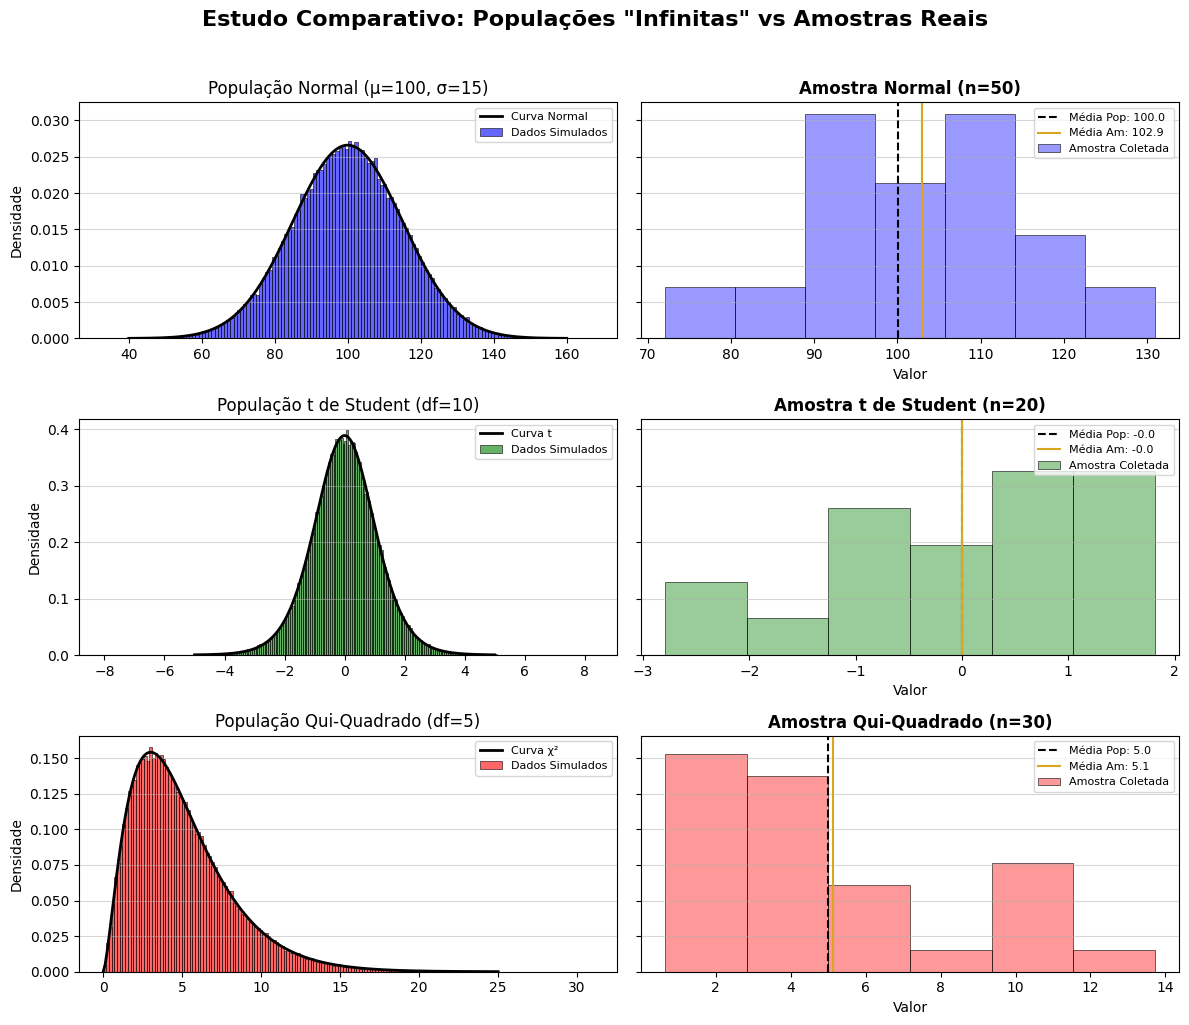

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações globais
np.random.seed(42)
figsize = (12, 10)

# --- 1. CENÁRIO NORMAL ---
mean, std = 100, 15
pop_normal = np.random.normal(mean, std, 100000)
amostra_normal = np.random.choice(pop_normal, size=50)

# --- 2. CENÁRIO T DE STUDENT ---
df_t = 10
pop_t = np.random.standard_t(df_t, 100000)
amostra_t = np.random.standard_t(df_t, size=20)

# --- 3. CENÁRIO QUI-QUADRADO ---
df_chi = 5
pop_chi = np.random.chisquare(df=df_chi, size=100000)
amostra_chi = np.random.choice(pop_chi, size=30)


# === CRIAÇÃO DO PLOT MESTRE ===
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=figsize, sharey='row', tight_layout=True)

data_scenarios = [
    (pop_normal, amostra_normal, 'População Normal (μ=100, σ=15)', 'Amostra Normal (n=50)', 'blue'),
    (pop_t, amostra_t, 'População t de Student (df=10)', 'Amostra t de Student (n=20)', 'green'),
    (pop_chi, amostra_chi, 'População Qui-Quadrado (df=5)', 'Amostra Qui-Quadrado (n=30)', 'red')
]

for i, (pop, amostra, pop_title, sample_title, color) in enumerate(data_scenarios):

    # --- Coluna 1: População ---
    ax_pop = axes[i, 0]
    sns.histplot(
        pop,
        bins='auto',        # seleção automática pelo método de Sturges/Scott/FD
        stat='density',     # equivalente a density=True no matplotlib
        color=color,
        alpha=0.6,
        edgecolor='black',
        linewidth=0.4,
        ax=ax_pop,
        label='Dados Simulados'
    )
    ax_pop.set_title(pop_title, fontsize=12)
    ax_pop.set_ylabel('Densidade', fontsize=10)
    ax_pop.grid(axis='y', alpha=0.5)

    # Curvas teóricas
    if 'Normal' in pop_title:
        x = np.linspace(mean - 4*std, mean + 4*std, 200)
        ax_pop.plot(x, stats.norm.pdf(x, mean, std), color='black', lw=2, label='Curva Normal')
    elif 'Student' in pop_title:
        x = np.linspace(-5, 5, 200)
        ax_pop.plot(x, stats.t.pdf(x, df_t), color='black', lw=2, label='Curva t')
    elif 'Qui' in pop_title:
        x = np.linspace(0, 25, 200)
        ax_pop.plot(x, stats.chi2.pdf(x, df_chi), color='black', lw=2, label='Curva χ²')
    ax_pop.legend(fontsize=8)

    # --- Coluna 2: Amostra ---
    ax_sample = axes[i, 1]
    sns.histplot(
        amostra,
        bins='auto',
        stat='density',
        color=color,
        alpha=0.4,
        edgecolor='black',
        linewidth=0.4,
        ax=ax_sample,
        label='Amostra Coletada'
    )
    ax_sample.set_title(sample_title, fontsize=12, fontweight='bold')
    ax_sample.set_xlabel('Valor', fontsize=10)
    ax_sample.grid(axis='y', alpha=0.5)

    ax_sample.axvline(pop.mean(), color='black', linestyle='--', label=f'Média Pop: {pop.mean():.1f}')
    ax_sample.axvline(amostra.mean(), color='goldenrod', linestyle='-', label=f'Média Am: {amostra.mean():.1f}')
    ax_sample.legend(fontsize=8, loc='upper right')

fig.suptitle('Estudo Comparativo: Populações "Infinitas" vs Amostras Reais', fontsize=16, fontweight='bold', y=1.02)
plt.show()

Cenário Normal (μ=100, σ=15)
O cenário mais rico em opções. Com n=50 você pode usar o Teste Z (se fingir que conhece σ da população) ou o Teste t de uma amostra (mais realista, pois na prática σ é desconhecido). Ambos testam se a média amostral é compatível com algum valor hipotético — por exemplo, "a média da população é realmente 100?". Também cabe um Intervalo de Confiança para μ para ver se o verdadeiro valor está dentro da margem estimada.
Cenário t de Student (df=10)

Desenhado para explorar o que acontece com caudas gordas e amostras pequenas (n=20). O teste natural é o Teste t de uma amostra, mas o mais interessante aqui é comparar com o Teste Z: com n=20 a diferença entre as duas distribuições é visível, e você consegue ver na prática por que o t existe. Também cabe um Teste de Normalidade (Shapiro-Wilk) para verificar se a amostra parece normal, já que a distribuição t com df=10 ainda tem caudas mais pesadas que a normal.
Cenário Qui-Quadrado (df=5)

Distribuição assimétrica, sempre positiva. Os testes naturais aqui são o Teste Qui-Quadrado de Aderência (a amostra segue a distribuição teórica?) e o Teste de Variância (χ² testa se σ² é igual a algum valor). É também o cenário ideal para mostrar por que não se deve aplicar um teste t cegamente — a assimetria viola os pressupostos.